# Part 3 — Application: Risk Segmentation and Classifying Ambiguous Records

**Project:** Privacy Risk Analysis and Automatic Classification in the GPT Plugin Ecosystem

**Research Question 4:** When we group plugins by the type of data they collect, do natural risky/safe clusters emerge? (clustering)

**Research Question 5:** Can the model we built in Part 2 be used to classify records with an ambiguous label (specifically the "Other" category in `data_type`, 3,544 records)?

**Plan for this section:**
1. Setting up the problem: moving from parameter-level to plugin-level — extracting each plugin's "data collection profile" (deduplicated to avoid a plugin's profile being skewed by a repeated parameter–plugin entry)
2. Clustering: grouping plugins by data collection profile, interpreting the clusters (is there a risky/safe split?)
3. Applying the Part 2 model to "Other" records, interpreting the results cautiously
4. Overall project summary

**A note on scope:** "sensitive share" below always means the combined share of the four project-selected sensitive categories (Security credentials, Personal information, Health information, Finance information) specifically — not a general, validated measure of privacy harm. Other categories not counted here, like Location or Message, can also carry privacy risk.

## Step 1 — Moving from Parameter-Level to Plugin-Level

In Parts 1 and 2, every row was a **parameter**. But Research Question 4 wants to group plugins (GPT Actions) — meaning we need to change our unit of analysis from parameter to **plugin**.

**Challenge:** `plugin_id_filenames` is a list — the same parameter can be used by multiple plugins, and (as we found while validating this analysis) the *same* plugin ID can appear more than once inside a single record's list. We explode the data into one row per (plugin, parameter) pair and then **deduplicate** repeated (record, plugin) pairs — otherwise a plugin's profile would be distorted by an accidental repeat rather than a genuine second parameter. After deduplication, there are **30,478** distinct parameter–plugin pairs.

**How we derive a plugin's profile:** for each plugin, we'll compute the **proportion** of its parameters that fall into each category (e.g. "30% of this plugin's parameters are Identifier, 10% Security credentials..."). We use a proportion, not a raw count — because plugins vary hugely in size (from 1 parameter to 1000+); what matters is not the plugin's size but *the profile of what it collects*.

**Minimum parameter threshold:** a plugin with only 1-2 parameters would have a meaningless "profile" (it would appear 100% in one category, which is chance, not a pattern). So we'll only keep plugins with at least **3 parameters** — this leaves us **2,968** out of 4,592 plugins, a large enough sample.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

DATA_PATH = '../backend/data/data_entries_final.json'

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)
df['text'] = (df['name'].fillna('') + '. ' + df['description'].fillna('')).str.strip()

df_exploded = df.explode('plugin_id_filenames').rename(columns={'plugin_id_filenames': 'plugin_id'}).drop_duplicates(['index', 'plugin_id']).reset_index(drop=True)

print('Parameter record count:', len(df))
print('(plugin, parameter) row count after exploding:', len(df_exploded))
print('Unique plugin count:', df_exploded['plugin_id'].nunique())
# Shared taxonomy/audit rules are used by the backend too.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "backend"))
from app.domain import disclosure_status, unambiguous_type_mapping


Parameter record count: 12811
(plugin, parameter) row count after exploding: 30478
Unique plugin count: 4592


In [2]:
MIN_PARAMS = 3

plugin_param_counts = df_exploded.groupby('plugin_id').size()
eligible_plugins = plugin_param_counts[plugin_param_counts >= MIN_PARAMS].index

df_exploded_filtered = df_exploded[df_exploded['plugin_id'].isin(eligible_plugins)]

plugin_category_counts = pd.crosstab(df_exploded_filtered['plugin_id'], df_exploded_filtered['main_data_type'])
plugin_profile = plugin_category_counts.div(plugin_category_counts.sum(axis=1), axis=0)

print(f'Plugins with {MIN_PARAMS}+ parameters: {len(plugin_profile)}')
print('Profile matrix shape:', plugin_profile.shape)
plugin_profile.head(3)

Plugins with 3+ parameters: 2968
Profile matrix shape: (2968, 25)


main_data_type                                      App metadata  \
plugin_id                                                          
g-009xFjOLC_OoDqO0qGP1tw2zGRYCYIfpUK                        0.25   
g-00y8F1eRb_APoRCDy5ffgP0bHoQMuTHeML                        0.00   
g-02IWjW9i4_gzm_cnf_brjSH6N13PZzuSsTMwtje1dt~gz...          0.00   

main_data_type                                      App usage data  \
plugin_id                                                            
g-009xFjOLC_OoDqO0qGP1tw2zGRYCYIfpUK                           0.0   
g-00y8F1eRb_APoRCDy5ffgP0bHoQMuTHeML                           0.7   
g-02IWjW9i4_gzm_cnf_brjSH6N13PZzuSsTMwtje1dt~gz...             0.0   

main_data_type                                      E-commerce data  \
plugin_id                                                             
g-009xFjOLC_OoDqO0qGP1tw2zGRYCYIfpUK                            0.0   
g-00y8F1eRb_APoRCDy5ffgP0bHoQMuTHeML                            0.0   
g-02IWjW9i4_gzm_cnf_brjS

## Step 2 — Clustering: How Many Natural Groups Are There?

**Intuition:** K-Means groups our eligible plugins into clusters by putting plugins with similar data-collection profiles (proportions across the 25 categories) together — with no labels given, purely by "which plugins resemble each other." Our goal: see whether one of these clusters comes out naturally "sensitive-data-heavy" (risky) and another "harmless/general-purpose" (safe).

**Standardization:** variance differs a lot across categories (e.g. the "Other" proportion varies a lot plugin to plugin, while "Health information" stays near zero for most plugins). Without standardizing, clustering would be shaped by just the 1-2 highest-variance categories. So we standardize every category (to mean 0, standard deviation 1) — so all 25 categories get an equal say in the clustering. Standardizing can also amplify the influence of a rare category with little real variance, so we treat this as one reasonable representation rather than the only valid one.

**How many clusters (K) to choose:** we don't guess this without looking at the data — we'll try several K values (2 through 10) and look at the **silhouette score**. This score measures how well each plugin "belongs" to its own cluster versus how far it is from other clusters; a higher score means more clearly separated clusters. Whatever K comes out best in this 2–10 range is a data-driven candidate, not proof of a true global optimum — a wider search and stability checks are a natural extension.

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
profile_scaled = scaler.fit_transform(plugin_profile)

k_range = range(2, 11)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(profile_scaled)
    score = silhouette_score(profile_scaled, labels)
    silhouette_scores.append(score)
    print(f'K={k}: silhouette score = {score:.3f}')

K=2: silhouette score = 0.230
K=3: silhouette score = 0.226
K=4: silhouette score = 0.202
K=5: silhouette score = 0.230
K=6: silhouette score = 0.221
K=7: silhouette score = 0.140
K=8: silhouette score = 0.159
K=9: silhouette score = 0.164
K=10: silhouette score = 0.268


Selected K: 10 (silhouette score: 0.268)


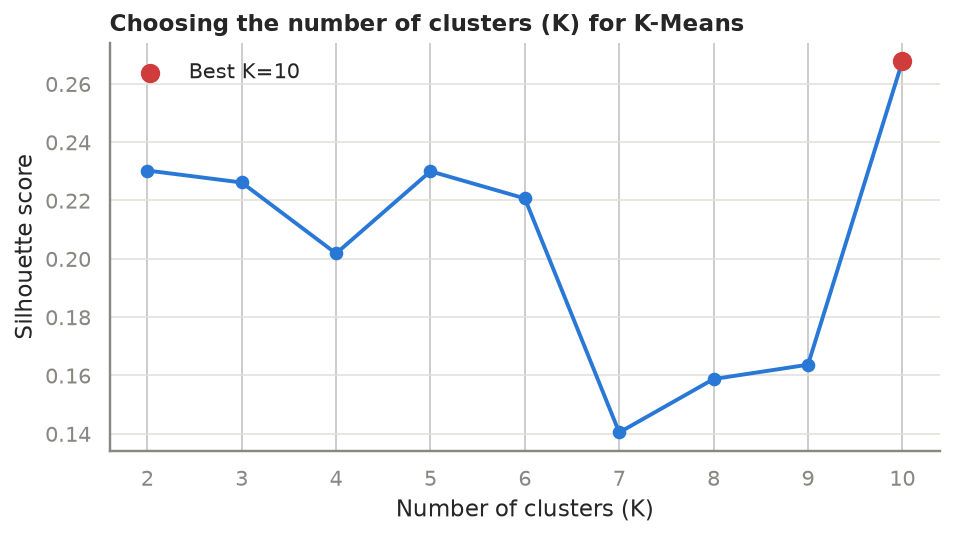

In [4]:
COLOR_MAIN = '#2a78d6'
COLOR_MUTED = '#898781'
COLOR_TEXT = '#0b0b0b'

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), silhouette_scores, marker='o', color=COLOR_MAIN, linewidth=2, markersize=6)

best_k = list(k_range)[int(np.argmax(silhouette_scores))]
best_score = max(silhouette_scores)
ax.scatter([best_k], [best_score], color='#d03b3b', zorder=5, s=80, label=f'Best K={best_k}')

ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Silhouette score')
ax.set_title('Choosing the number of clusters (K) for K-Means', loc='left', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED)
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False)

plt.tight_layout()

import os
os.makedirs('exported_charts', exist_ok=True)
plt.savefig('exported_charts/rq4_silhouette_scores.png', dpi=150, bbox_inches='tight')

plt.show()

print(f'Selected K: {best_k} (silhouette score: {best_score:.3f})')

In [5]:
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
plugin_profile['cluster'] = final_kmeans.fit_predict(profile_scaled)

print(f'Plugin distribution across {best_k} clusters:')
print(plugin_profile['cluster'].value_counts().sort_index())

Plugin distribution across 10 clusters:
cluster
0     531
1     198
2     162
3      19
4    1541
5       6
6     153
7      13
8     342
9       3
Name: count, dtype: int64


### Finding (choosing K)

Two things are worth noting:

1. **Silhouette scores are low-to-moderate and non-monotonic** (ranging from 0.140 at K=7 to 0.268 at K=10) — this shows that plugins do not form clusters with clean, sharply separated data-collection profiles. This is actually expected: real-world data rarely splits into perfect clusters, and most plugins probably mix several categories.
2. The best score in the searched range is at K=10, but it sits at the *upper edge* of the range we tried (2 through 10) — so this is "the best we found in 2–10," not proof that 10 is a true global optimum. Cluster sizes are also very unbalanced: two large clusters (1,541 and 531 plugins) cover most of the data, while the remaining clusters are much smaller (some with only 3-19 plugins). These small clusters could be noise, but they could also be **very specific plugin groups concentrated on a single category** — we'll find out by looking at the cluster profiles in the next step.

For now we'll accept K=10 as the data-driven choice and move on; we'll decide whether the small clusters are meaningful or noise through profile analysis.

## Step 3 — Interpreting the Clusters: Is There a Risky/Safe Split?

We'll compute each cluster's "average profile" (centroid) and look at two things:
1. **What categories do the plugins in that cluster collect the most?** (top 3 dominant categories)
2. **What is that cluster's total share across the 4 sensitive categories** (Security credentials, Personal information, Health information, Finance information)? We'll call this the "sensitive share" and rank clusters by it. This is a share of these four *selected* categories specifically, not a validated measure of overall privacy harm — other categories (Location, Identifier, Message) can also carry risk and aren't counted here.

If the answer to Research Question 4 is "yes," one or a few clusters with a high sensitive share should stand clearly apart from the low ones.

In [6]:
SENSITIVE_CATEGORIES = ['Security credentials', 'Personal information', 'Health information', 'Finance information']

centroids = plugin_profile.groupby('cluster').mean()
cluster_sizes = plugin_profile['cluster'].value_counts().sort_index()
sensitive_share = centroids[SENSITIVE_CATEGORIES].sum(axis=1)

cluster_summary = pd.DataFrame({
    'plugin_count': cluster_sizes,
    'sensitive_share': sensitive_share,
})
cluster_summary['dominant_categories'] = [
    ', '.join(f'{cat} (%{val*100:.0f})' for cat, val in centroids.loc[c].sort_values(ascending=False).head(3).items())
    for c in cluster_summary.index
]
cluster_summary = cluster_summary.sort_values('sensitive_share', ascending=False)
cluster_summary['sensitive_share'] = (cluster_summary['sensitive_share'] * 100).round(1)
cluster_summary

         plugin_count  sensitive_share  \
cluster                                  
2                 162             35.1   
1                 198             31.1   
9                   3             10.5   
8                 342              4.9   
0                 531              3.2   
3                  19              3.1   
7                  13              2.9   
4                1541              0.9   
5                   6              0.0   
6                 153              0.0   

                                       dominant_categories  
cluster                                                     
2        Personal information (%34), Message (%18), Ide...  
1        Security credentials (%25), App usage data (%1...  
9        Real estate data (%44), Location (%17), App us...  
8         Time (%29), Location (%13), App usage data (%13)  
0        Other (%28), Identifier (%23), App usage data ...  
3        Location (%41), Weather information (%27), App...  
7      

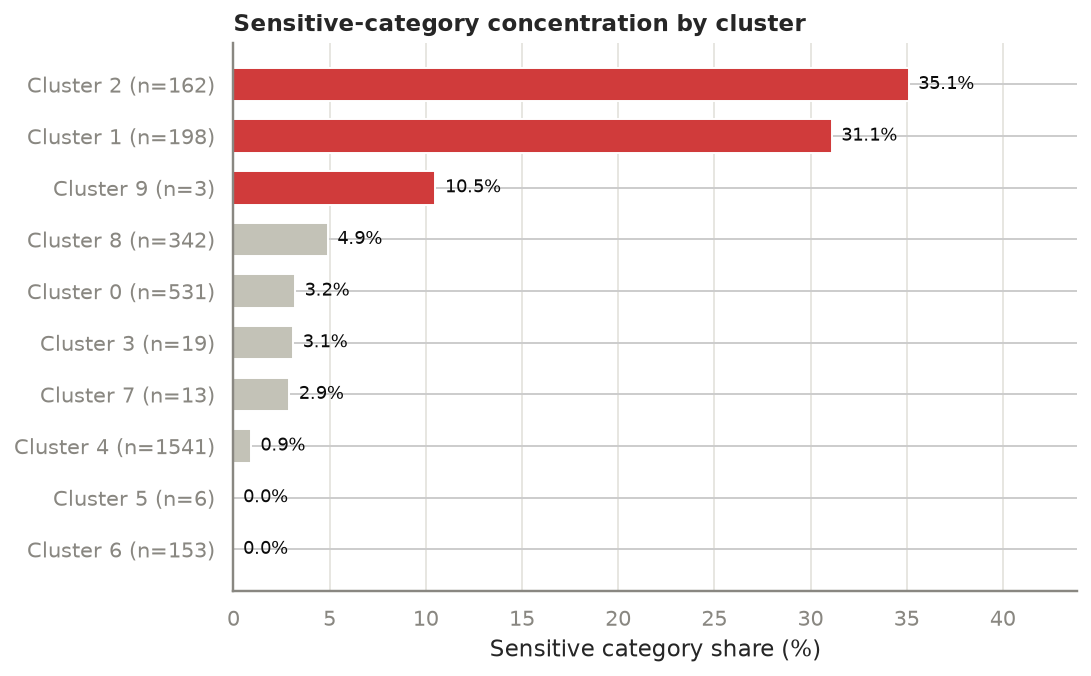

In [7]:
COLOR_SENSITIVE = '#d03b3b'
COLOR_NEUTRAL = '#c3c2b7'
COLOR_TEXT = '#0b0b0b'
COLOR_MUTED = '#898781'

ordered = cluster_summary.sort_values('sensitive_share')
colors = [COLOR_SENSITIVE if v >= 10 else COLOR_NEUTRAL for v in ordered['sensitive_share']]
labels = [f'Cluster {c} (n={n})' for c, n in zip(ordered.index, ordered['plugin_count'])]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(labels, ordered['sensitive_share'], color=colors, height=0.65)

for bar, val in zip(bars, ordered['sensitive_share']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', ha='left', fontsize=9, color=COLOR_TEXT)

ax.set_xlabel('Sensitive category share (%)')
ax.set_title('Sensitive-category concentration by cluster', loc='left', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED)
ax.grid(axis='x', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)
ax.set_xlim(0, ordered['sensitive_share'].max() * 1.25)

plt.tight_layout()

import os
os.makedirs('exported_charts', exist_ok=True)
plt.savefig('exported_charts/rq4_cluster_sensitivity.png', dpi=150, bbox_inches='tight')

plt.show()

### Finding (Research Question 4)

The answer isn't a clear "yes," but it isn't a full "no" either — a more nuanced picture emerges, now measured on the corrected, deduplicated profiles:

- Instead of producing a clean binary split on the sensitive/non-sensitive axis, clustering surfaces **functional/thematic groups**: personal-information & messaging (Cluster 2, 162 plugins, 35.1% sensitive share), security-credentials & app usage (Cluster 1, 198 plugins, 31.1%), a small real-estate cluster (Cluster 9, 3 plugins, 10.5%), and several larger, low-sensitivity, general-purpose clusters — including the two biggest, a general app-usage cluster (Cluster 4, 1,541 plugins, 0.9%) and an "Other"/Identifier-heavy cluster (Cluster 0, 531 plugins, 3.2%).
- The sensitive-category share is spread across clusters with no sharp jump into a clean two-group split: highest at 35.1% (Cluster 2), down to 0% for two clusters (5 and 6) that collect only vehicle/identifier or app-metadata/query data.
- **"Largest" and "riskiest" are different clusters** — worth not conflating: the two largest clusters (Cluster 4: 1,541 plugins, Cluster 0: 531 plugins) together make up **~69.8%** of all eligible plugins, but their sensitive shares are low (0.9% and 3.2%). The two clusters with the highest sensitive share (Cluster 2: 35.1%, Cluster 1: 31.1%) together make up only **~12.1%** of all eligible plugins (162+198=360 / 2,968 plugins).
- Cluster IDs here are specific to this corrected, deduplicated run — they should not be compared by number to any earlier, pre-deduplication analysis. A low sensitive share also doesn't mean a cluster is "safe" overall — it's low only on these four selected categories.

**Conclusion:** the natural clusters don't split into "risky vs. safe," but being able to **rank** clusters by sensitive-data density is itself a useful risk-segmentation tool — e.g. the plugins in Cluster 2 and Cluster 1 (the two clusters with the highest sensitive share, together ~12.1% of eligible plugins) can be flagged as the groups that most deserve review priority.

## Step 4 — Applying the Model to "Other" Records (Research Question 5)

**A critical methodology decision:** we can't just reuse Part 2's `data_type` model as-is, because it saw "Other" as a **valid class** during training. Here our goal is different: the "Other" label is already unreliable (it means ambiguous/unlabeled), so we shouldn't even tell the model "Other exists as a class" — otherwise the model will likely just predict "Other" for everything again, and we'll have learned nothing.

**Solution:** we'll retrain the model using **only the non-"Other"** 9,267 records, over the real 144 `data_type` values (again grouping rare classes, 77 usable classes + 1 rare bucket = 78 classes). This way, when the model looks at an "Other" record, it will be forced to suggest the **most likely** option among the 78 real categories — it won't be able to say "I don't know" and fall back to Other.

**Confidence score:** the model produces a probability distribution for every prediction. We'll use the highest probability as the **"confidence score"** — we should be very cautious about low-confidence predictions (e.g. if the model says 15% A, 14% B), since these are closer to a coin flip than a genuine suggestion. This score is also not directly comparable to the known-label test-set accuracy from earlier — "Other" records are a different, unlabeled population, so a high score here doesn't itself prove correctness.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

RARE_THRESHOLD = 10
RARE_BUCKET_INTERNAL = 'Nadir tür (birleştirilmiş)'
RARE_BUCKET_LABEL = 'Rare type (merged)'

df_known = df[df['data_type'] != 'Other'].copy()
df_other = df[df['data_type'] == 'Other'].copy()

known_type_counts = df_known['data_type'].value_counts()
rare_types = known_type_counts[known_type_counts < RARE_THRESHOLD].index
df_known['data_type_grouped'] = df_known['data_type'].where(~df_known['data_type'].isin(rare_types), RARE_BUCKET_INTERNAL)

print('Non-"Other" record count:', len(df_known))
print('"Other" record count:', len(df_other))
print('Class count (after grouping):', df_known['data_type_grouped'].nunique())

X_known = df_known['text']
y_known = df_known['data_type_grouped']

X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(
    X_known, y_known, test_size=0.2, random_state=42, stratify=y_known
)

tfidf_other = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_train_k_tfidf = tfidf_other.fit_transform(X_train_k)
X_test_k_tfidf = tfidf_other.transform(X_test_k)

model_other = LogisticRegression(max_iter=1000, random_state=42)
model_other.fit(X_train_k_tfidf, y_train_k)

y_pred_k = model_other.predict(X_test_k_tfidf)
print()
print(f'Accuracy on its own test set: {accuracy_score(y_test_k, y_pred_k):.3f}')
print(f'Macro F1 on its own test set: {f1_score(y_test_k, y_pred_k, average="macro"):.3f}')

Non-"Other" record count: 9267
"Other" record count: 3544
Class count (after grouping): 78

Accuracy on its own test set: 0.690
Macro F1 on its own test set: 0.429


In [9]:
# Apply the model to all "Other" records it has never seen.
X_other_tfidf = tfidf_other.transform(df_other['text'])

other_pred_proba = model_other.predict_proba(X_other_tfidf)
other_predictions = model_other.classes_[np.argmax(other_pred_proba, axis=1)]
other_confidence = other_pred_proba.max(axis=1)

df_other['predicted_data_type'] = other_predictions
df_other['confidence'] = other_confidence

print('Prediction score distribution:')
print(df_other['confidence'].describe().round(3))

Prediction score distribution:
count    3544.000
mean        0.289
std         0.172
min         0.081
25%         0.198
50%         0.209
75%         0.341
max         0.993
Name: confidence, dtype: float64


**First observation:** on its own test set the model performs reasonably (69.0% accuracy, very close to Part 2's `data_type` model — as expected, since it's the same method). But once applied to "Other" records, confidence scores are generally **low**: the median is only 20.9%. This isn't surprising — the "Other" label likely already contains genuinely ambiguous/general records, and the model reflects that as "uncertainty." Still, some records reach up to 99% confidence — meaning some "Other" records may actually belong to a clear category but were mislabeled. The known-label test set and these uncertain "Other" records are different populations, though: a high maximum predicted probability here doesn't independently establish correctness, and a low one doesn't prove the original "Other" label was wrong.

Let's now look at the confidence-score distribution and what the high-confidence predictions suggest.

Records with confidence >= 0.5: 411 (11.6%)


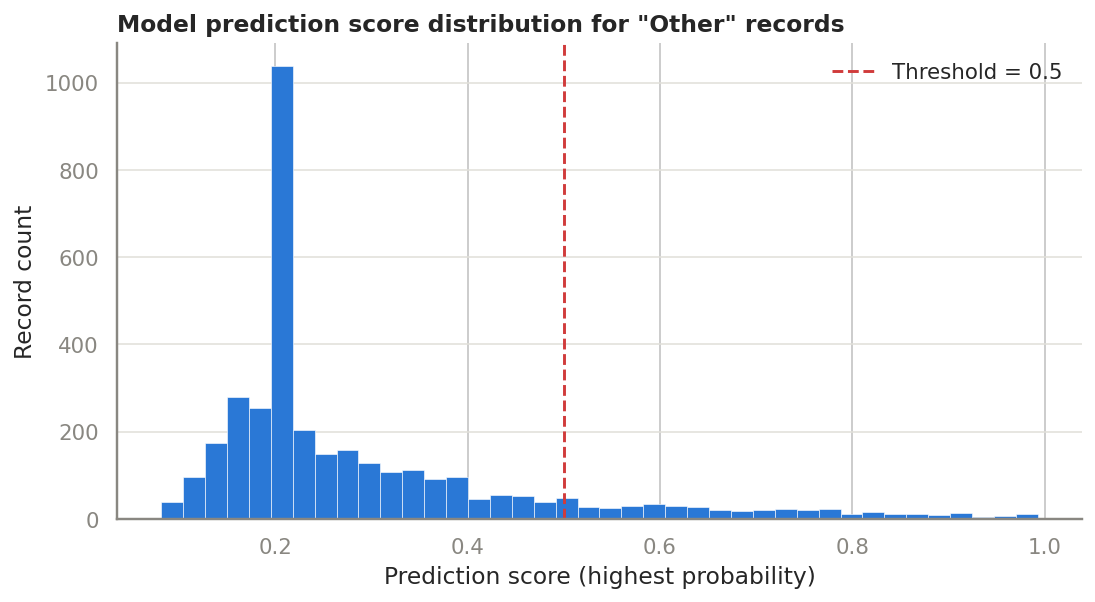

In [10]:
COLOR_MAIN = '#2a78d6'
COLOR_CONFIDENT = '#1baf7a'
COLOR_MUTED = '#898781'
COLOR_TEXT = '#0b0b0b'
CONFIDENCE_THRESHOLD = 0.5

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df_other['confidence'], bins=40, color=COLOR_MAIN, edgecolor='white', linewidth=0.3)
ax.axvline(CONFIDENCE_THRESHOLD, color='#d03b3b', linewidth=1.5, linestyle='--',
           label=f'Threshold = {CONFIDENCE_THRESHOLD}')

ax.set_xlabel('Prediction score (highest probability)')
ax.set_ylabel('Record count')
ax.set_title('Model prediction score distribution for "Other" records', loc='left', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED)
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False)

plt.tight_layout()

import os
os.makedirs('exported_charts', exist_ok=True)
plt.savefig('exported_charts/rq5_other_confidence_distribution.png', dpi=150, bbox_inches='tight')

plt.show()

n_confident = (df_other['confidence'] >= CONFIDENCE_THRESHOLD).sum()
print(f'Records with confidence >= {CONFIDENCE_THRESHOLD}: {n_confident} ({n_confident/len(df_other)*100:.1f}%)')

In [11]:
confident_other = df_other[df_other['confidence'] >= CONFIDENCE_THRESHOLD]

print(f'Top 15 categories suggested by confident predictions (n={len(confident_other)}):')
print(confident_other['predicted_data_type'].value_counts().head(15))

Top 15 categories suggested by confident predictions (n=411):
predicted_data_type
Current session setting    218
Resource IDs                80
Search query                39
Query filter                35
User identifiers             6
URLs                         5
Ticker symbol                4
Date                         4
Email address                3
API key                      3
Text messages                2
State/province               2
Time period                  2
Multimedia data              2
Database information         2
Name: count, dtype: int64


**The most privacy-critical question:** how many of these confident predictions point to a **sensitive category** (at the `main_data_type` level)? In other words, are there records labeled "Other" that might actually be a sensitive data type? To check this we'll map each `data_type` value to the `main_data_type` it belongs to. This mapping is only reliable when a `data_type` maps to exactly one `main_data_type`; where the taxonomy is genuinely many-to-many, we leave the mapping **unresolved** rather than silently assigning the most common broad label.

In [12]:
SENSITIVE_CATEGORIES = ['Security credentials', 'Personal information', 'Health information', 'Finance information']

data_type_to_main = unambiguous_type_mapping(df_known)

confident_other = confident_other.copy()
confident_other['predicted_main_type'] = confident_other['predicted_data_type'].map(data_type_to_main)
confident_other['predicted_is_sensitive'] = confident_other['predicted_main_type'].isin(SENSITIVE_CATEGORIES)

n_sensitive_flagged = confident_other['predicted_is_sensitive'].sum()
print(f'Of the {len(confident_other)} above-threshold predicted "Other" records, '
      f'{n_sensitive_flagged} point to a sensitive category.')
print()
print('Suggested main_data_type distribution for these records:')
print(confident_other.loc[confident_other['predicted_is_sensitive'], 'predicted_main_type'].value_counts())
confident_other['mapping_status'] = np.where(confident_other['predicted_main_type'].isna(), 'unresolved', 'unique')
print('Unresolved broad-category mappings:', int(confident_other['predicted_main_type'].isna().sum()))


Of the 411 above-threshold predicted "Other" records, 7 point to a sensitive category.

Suggested main_data_type distribution for these records:
predicted_main_type
Security credentials    4
Personal information    3
Name: count, dtype: int64
Unresolved broad-category mappings: 0


In [13]:
sensitive_examples = confident_other[confident_other['predicted_is_sensitive']].sort_values('confidence', ascending=False)
sensitive_examples[['name', 'description', 'predicted_data_type', 'predicted_main_type', 'confidence']].head(10)

             name              description predicted_data_type  \
874         email                                Email address   
12055       email     Email of the vendor.       Email address   
1721          key                                      API key   
3086       skills             过滤 skill key             API key   
10025         KEY                                      API key   
4287        token  Identifier of the token       Access tokens   
3971   email_type          The email type.       Email address   

        predicted_main_type  confidence  
874    Personal information    0.909600  
12055  Personal information    0.898941  
1721   Security credentials    0.822185  
3086   Security credentials    0.822185  
10025  Security credentials    0.822185  
4287   Security credentials    0.506541  
3971   Personal information    0.503544  

### Finding (Research Question 5)

**Answer: partially yes, but only for a small, carefully selected subset.**

- Only **11.6% (411 records)** of the 3,544 "Other" records cross the confidence threshold (50%). The large remaining majority leaves the model uncertain too — these records are probably genuinely ambiguous/general-purpose, and the "Other" label isn't unfair for them.
- Most confident predictions are already intuitive categories: general-purpose technical fields like `Current session setting`, `Resource IDs`, `Search query`.
- But **7 records** confidently point to a **sensitive category** (`Security credentials` or `Personal information`). Looking at the examples, this isn't surprising at all: records with `name="email"`, `name="key"`, `name="KEY"`, `name="token"` are suggested as "Email address" / "API key" / "Access tokens" with 50-91% confidence — in the original dataset these are labeled "Other," but their names alone make it obvious they're sensitive data.
- All above-threshold predictions' fine-to-broad category mappings resolved cleanly this time (0 unresolved).

**Overall conclusion:** the model can't reliably reclassify **all** "Other" records — but for a small subset (**high-confidence predictions**), it can catch genuinely mislabeled sensitive data types. A more sound practical use is to use this model not for "automatic relabeling" but for **generating a review-priority list** — the few hundred confidently predicted, sensitive-pointing records form a reasonable priority list for human review. These flags are **candidates, not confirmed discoveries** — e.g. `skills` → API key or `email_type` → Email address could well be false positives, and no precision interval can be estimated for this unlabeled population without human-reviewed ground truth. The 0.5 threshold itself is an uncalibrated prediction-score cutoff, not a confidence interval.

## Appendix — Privacy Policy Audit: Is the Collected Data Disclosed in the Policy?

**Note:** the `backend/final_results/` dataset used in this section was not produced by this project's own analysis pipeline — it was produced and published by the authors of the source paper (Wu, Y., Jaff, E., Yang, K., Zhang, N., & Iqbal, U. (2025). *An In-Depth Investigation of Data Collection in LLM App Ecosystems*. IMC '25. https://doi.org/10.1145/3730567.3732912), which is also the source of this project's main dataset and category taxonomy — see the project README's Data Sources & Attribution section. It's a separate, smaller source (381 plugin files) from the main dataset (12,811 records). In that work, each collected data parameter was compared against sentences extracted from that plugin's own privacy policy and labeled with one of five categories: `CLEAR` (clearly discloses), `VAGUE` (vaguely discloses), `AMBIGUOUS` (unclear whether it discloses), `INCORRECT` (incorrectly/misleadingly discloses), `OMITTED` (this sentence doesn't disclose it). What we do here is read this pre-labeled data and compute a parameter's overall disclosure status (based on its best-matching sentence, in that same priority order) — if no sentence discloses it, `UNDISCLOSED`.

Question: **Do plugins disclose what they collect in their privacy policies?**

In [14]:
from pathlib import Path
from collections import Counter

FINAL_RESULTS_DIR = Path('../backend/final_results')

def item_disclosure_status(item):
    return disclosure_status(item)[0]


status_counts = Counter()
for path in sorted(FINAL_RESULTS_DIR.glob('*.json')):
    try:
        items = json.loads(path.read_text(encoding='utf-8'))
    except (json.JSONDecodeError, UnicodeDecodeError):
        continue
    for item in items:
        status = item_disclosure_status(item)
        if status == 'NO_POLICY_TEXT':
            continue  # no comparable policy text exists for this parameter
        status_counts[status] += 1

total_audited = sum(status_counts.values())
print(f'Parameter count with comparable policy text: {total_audited}')
print(status_counts)

Parameter count with comparable policy text: 308
Counter({'UNDISCLOSED': 278, 'DISCLOSED_CLEAR': 16, 'DISCLOSED_VAGUE': 7, 'DISCLOSED_INCORRECT': 6, 'DISCLOSED_AMBIGUOUS': 1})


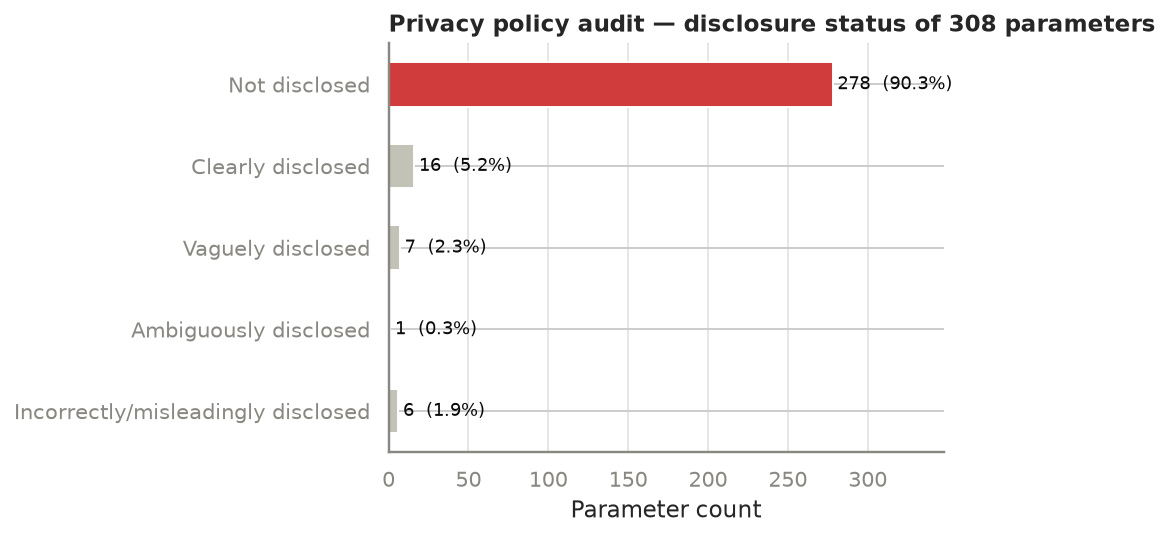

In [15]:
COLOR_SENSITIVE = '#d03b3b'
COLOR_NEUTRAL = '#c3c2b7'
COLOR_TEXT = '#0b0b0b'
COLOR_MUTED = '#898781'

labels_map = {
    'UNDISCLOSED': 'Not disclosed',
    'DISCLOSED_CLEAR': 'Clearly disclosed',
    'DISCLOSED_VAGUE': 'Vaguely disclosed',
    'DISCLOSED_AMBIGUOUS': 'Ambiguously disclosed',
    'DISCLOSED_INCORRECT': 'Incorrectly/misleadingly disclosed',
}
order = ['UNDISCLOSED', 'DISCLOSED_CLEAR', 'DISCLOSED_VAGUE', 'DISCLOSED_AMBIGUOUS', 'DISCLOSED_INCORRECT']
values = [status_counts[k] for k in order]
pcts = [v / total_audited * 100 for v in values]
colors = [COLOR_SENSITIVE if k == 'UNDISCLOSED' else COLOR_NEUTRAL for k in order]
labels = [labels_map[k] for k in order]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(labels[::-1], values[::-1], color=colors[::-1], height=0.55)

for bar, v, p in zip(bars, values[::-1], pcts[::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2, f'{v}  ({p:.1f}%)',
            va='center', ha='left', fontsize=9, color=COLOR_TEXT)

ax.set_xlabel('Parameter count')
ax.set_title(f'Privacy policy audit — disclosure status of {total_audited} parameters',
             loc='left', fontsize=12, fontweight='bold')
ax.set_xlim(0, max(values) * 1.25)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED)
ax.grid(axis='x', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()

import os
os.makedirs('exported_charts', exist_ok=True)
plt.savefig('exported_charts/rq6_policy_disclosure.png', dpi=150, bbox_inches='tight')

plt.show()

## Appendix — Research Question 7: Are the "Sensitive" Parameters Also the Undisclosed Ones?

**Question:** among the parameters audited for policy disclosure (RQ6), how many are *both* a sensitive category (RQ1's four-category definition) *and* completely undisclosed?

This combines two analyses that were previously kept separate: RQ1's definition of "sensitive" (`main_data_type` in Security credentials / Personal information / Health information / Finance information) and RQ6's policy-disclosure audit, which uses its own, finer 30-label taxonomy (`data_type`) over a different, smaller sample (308 comparable parameters, from the 381-plugin audit dataset). The two taxonomies aren't the same, so a hand mapping is needed for the labels that appear in both.

**Mapping used:** only labels that unambiguously belong to one RQ1 category are mapped — `Passwords` → Security credentials; `Email address`, `Name`, `Phone number` → Personal information; `Other financial info`, `Purchase history` → Finance information. This mapping is a new interpretive choice made for this appendix, not previously defined anywhere else in this project. It is justified using the source paper's own definitions: Table 4 lists "Purchase history" and "Income information" as Finance-information subtypes, and Figure 10's caption explicitly places "exact address" under Location rather than Personal information — which is why the ambiguous `Address` label (8 occurrences in this audit) is deliberately left unmapped rather than guessed. **No label in this audit's 30-label taxonomy corresponds to Health information at all**, so this appendix cannot say anything about health-data disclosure specifically.

In [16]:
import sys
sys.path.insert(0, str(Path.cwd().parent))
from analysis.metrics import wilson_interval

# See the markdown cell above for why each of these data_type -> main_data_type
# mappings is safe to make by hand, and why "Address" and Health information
# are deliberately excluded rather than guessed.
SENSITIVE_TYPE_MAP = {
    'Passwords': 'Security credentials',
    'Email address': 'Personal information',
    'Name': 'Personal information',
    'Phone number': 'Personal information',
    'Other financial info': 'Finance information',
    'Purchase history': 'Finance information',
}

sensitive_rows = []
for path in sorted(FINAL_RESULTS_DIR.glob('*.json')):
    try:
        items = json.loads(path.read_text(encoding='utf-8'))
    except (json.JSONDecodeError, UnicodeDecodeError):
        continue
    for item in items:
        status = item_disclosure_status(item)
        if status == 'NO_POLICY_TEXT':
            continue
        data_type = item.get('data_type')
        if data_type in SENSITIVE_TYPE_MAP:
            sensitive_rows.append({'data_type': data_type, 'main_type': SENSITIVE_TYPE_MAP[data_type], 'status': status})

sensitive_audit = pd.DataFrame(sensitive_rows)
n_sensitive = len(sensitive_audit)
n_undisclosed_sensitive = int((sensitive_audit['status'] == 'UNDISCLOSED').sum())

print(f'Of {total_audited} audited parameters, {n_sensitive} map to a sensitive category:')
print(sensitive_audit['main_type'].value_counts())
print()
print(f'Of those {n_sensitive}, {n_undisclosed_sensitive} are UNDISCLOSED '
      f'({n_undisclosed_sensitive / n_sensitive * 100:.1f}% of sensitive ones, '
      f'{n_undisclosed_sensitive / total_audited * 100:.1f}% of all {total_audited} audited).')

ci_of_sensitive = wilson_interval(n_undisclosed_sensitive, n_sensitive)
ci_of_all = wilson_interval(n_undisclosed_sensitive, total_audited)
print(f'95% Wilson CI (of the {n_sensitive} sensitive ones): [{ci_of_sensitive[0]*100:.1f}%, {ci_of_sensitive[1]*100:.1f}%]')
print(f'95% Wilson CI (of all {total_audited} audited): [{ci_of_all[0]*100:.1f}%, {ci_of_all[1]*100:.1f}%]')

Of 308 audited parameters, 20 map to a sensitive category:
main_type
Personal information    16
Finance information      3
Security credentials     1
Name: count, dtype: int64

Of those 20, 18 are UNDISCLOSED (90.0% of sensitive ones, 5.8% of all 308 audited).
95% Wilson CI (of the 20 sensitive ones): [69.9%, 97.2%]
95% Wilson CI (of all 308 audited): [3.7%, 9.0%]


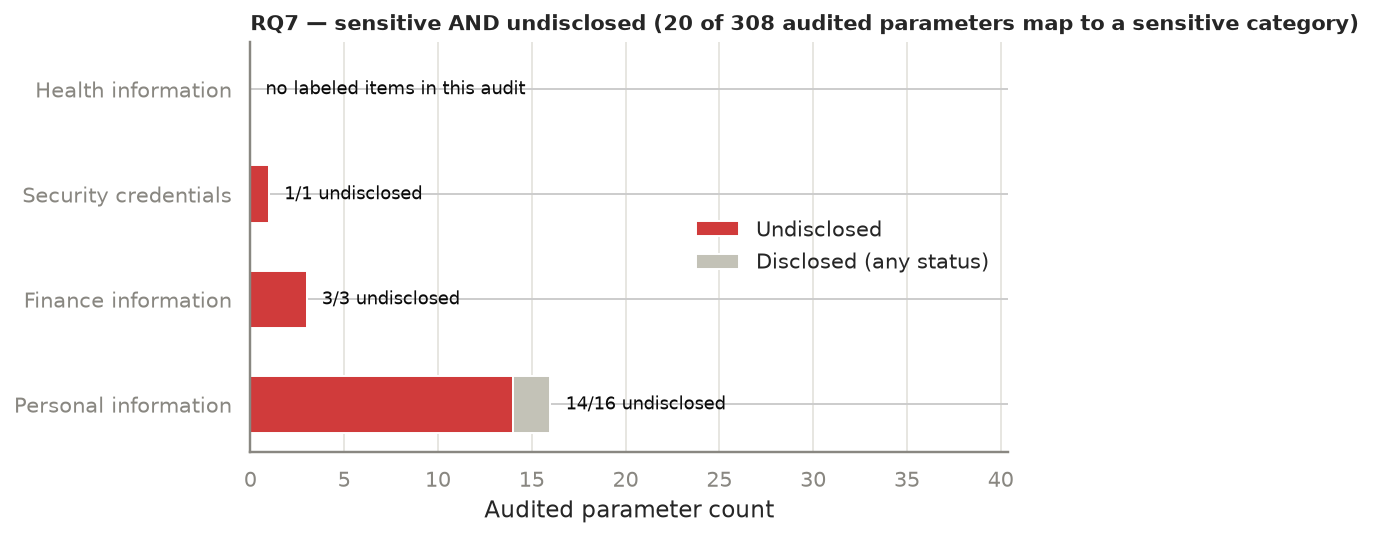

In [17]:
COLOR_SENSITIVE = '#d03b3b'
COLOR_NEUTRAL = '#c3c2b7'
COLOR_TEXT = '#0b0b0b'
COLOR_MUTED = '#898781'

cat_order = ['Personal information', 'Finance information', 'Security credentials', 'Health information']
undisclosed_counts = {cat: int(((sensitive_audit['main_type'] == cat) & (sensitive_audit['status'] == 'UNDISCLOSED')).sum()) for cat in cat_order}
disclosed_counts = {cat: int(((sensitive_audit['main_type'] == cat) & (sensitive_audit['status'] != 'UNDISCLOSED')).sum()) for cat in cat_order}
undisclosed_vals = [undisclosed_counts[c] for c in cat_order]
disclosed_vals = [disclosed_counts[c] for c in cat_order]

fig, ax = plt.subplots(figsize=(7.5, 4))
y = np.arange(len(cat_order))

ax.barh(y, undisclosed_vals, color=COLOR_SENSITIVE, height=0.55, label='Undisclosed')
ax.barh(y, disclosed_vals, left=undisclosed_vals, color=COLOR_NEUTRAL, height=0.55, label='Disclosed (any status)')

xmax = max(u + d for u, d in zip(undisclosed_vals, disclosed_vals)) * 2.4 + 2
offset = xmax * 0.02
for yi, (u, d) in enumerate(zip(undisclosed_vals, disclosed_vals)):
    total = u + d
    label = f'{u}/{total} undisclosed' if total else 'no labeled items in this audit'
    ax.text(total + offset, yi, label, va='center', ha='left', fontsize=9, color=COLOR_TEXT)

ax.set_yticks(y, cat_order)
ax.set_xlabel('Audited parameter count')
ax.set_title(f'RQ7 — sensitive AND undisclosed ({n_sensitive} of {total_audited} audited parameters map to a sensitive category)',
             loc='left', fontsize=11, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED)
ax.grid(axis='x', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)
ax.set_xlim(0, xmax)
ax.legend(frameon=False, loc='center right')

plt.tight_layout()

import os
os.makedirs('exported_charts', exist_ok=True)
plt.savefig('exported_charts/rq7_sensitive_undisclosed.png', dpi=150, bbox_inches='tight')

plt.show()

### Finding (Research Question 7)

Of the 308 audited parameters, only **20** map to one of the three sensitive categories present in this audit's taxonomy (16 Personal information, 3 Finance information, 1 Security credentials — 0 Health information, since no health-related label exists in this taxonomy at all). Of those 20, **18 (90.0%) are UNDISCLOSED** — 95% Wilson CI [69.9%, 97.2%], wide because the sample is small (n=20). As a share of all 308 audited parameters, that's 18/308 = **5.8%**.

**A coincidence worth flagging, not overclaiming:** 5.8% is numerically identical to the source paper's own separately-computed headline figure ("the data collection of only 5.8% of Actions is consistent with their disclosures," aggregated at the Action level). These are two different statistics — a different aggregation unit (parameter here vs. Action there), a different numerator/denominator definition, and a project-specific sensitive-category mapping the paper itself never defines. Treat the matching digits as a coincidence, not the same finding restated.

**Limitations:** n=20 is small — relabeling even a single item would move the estimate several points, hence the wide confidence interval. The `data_type` → `main_data_type` mapping above is this project's own judgment call, made explicit and justified (not silently assumed) precisely so it can be checked or challenged. Because no Health-information label exists in this particular audit's taxonomy, this appendix is silent on health-data disclosure specifically — a differently-sourced audit would be needed to check that.

## Summary — Part 3

**Research Question 4 answer:** clustering plugins by (deduplicated) data-collection profile doesn't produce a clean "risky vs. safe" binary split. Instead, **functional/thematic clusters** emerge (personal information & messaging, security credentials & app usage, general-purpose, metadata-only, ...) and sensitive-category density is spread across them (0%–35.1%). "Largest" and "riskiest" are different clusters: the two largest clusters (Cluster 4 + Cluster 0) make up ~69.8% of eligible plugins but have low sensitive shares (0.9%, 3.2%); the two clusters with the highest sensitive share (Cluster 2 + Cluster 1) make up only ~12.1%. Practical takeaway: the clusters are not a binary safe/risky label; their sensitive-category share can be used to **prioritize clusters for closer review**, but it is not a validated risk score.

**Research Question 5 answer:** we retrained Part 2's model without "Other" and applied it to the 3,544 "Other" records. The result is **partially positive**: only 11.6% of records can be confidently reclassified (≥50%) — most remain genuinely ambiguous. But within this small confident subset, **clearly sensitive** records like `name="email"`, `name="key"`, `name="token"` are correctly caught. The model can be used not for automatic relabeling, but for generating a **human-review priority list** — these are unverified candidates, not confirmed discoveries.

Part 4 puts the classification model behind both research questions on rigorous footing: a held-out validation split selects the best of three candidate models, and 2,000-resample bootstrap confidence intervals quantify how much better it really is than the original baseline used above.

# Distinct-parameter Action profiles

## Corrected sample
30478 distinct parameter–Action pairs; 2968 Actions have at least three distinct parameter records.

## Cluster results
Best K within 2–10: 10; silhouette 0.2677.
|Cluster|Actions|Selected sensitive-category share|Top categories|
|---|---:|---:|---|
|0|531|3.2%|Other, Identifier, App usage data|
|1|198|31.1%|Security credentials, App usage data, Query|
|2|162|35.1%|Personal information, Message, Identifier|
|3|19|3.1%|Location, Weather information, App usage data|
|4|1541|0.9%|App usage data, Query, Web and network data|
|5|6|0.0%|Vehicle information, Identifier, App usage data|
|6|153|0.0%|App metadata, Query, Files and documents|
|7|13|2.9%|E-commerce data, Identifier, Web and network data|
|8|342|4.9%|Time, Location, App usage data|
|9|3|10.5%|Real estate data, Location, App usage data|

## Interpretation
These are functional category profiles, not safe/unsafe labels. The four selected categories omit other potentially sensitive data, including location and messages. Cluster IDs changed after deduplication and cannot be matched by number to older results. K is exploratory; small clusters and the upper search boundary require caution. Rankings in FACTS distinguish cluster size from selected-category share.

Above-threshold flags remain unverified; see Part 4 for confidence intervals.
